# Exercise 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [28]:
#generate data
def data(d):
    dt = .1
    std_dev = 1
    vf_size = (15,15)
    n_bins = round(d / float(dt))
    s = std_dev * np.random.randn(n_bins,vf_size[0],vf_size[1])
    return n_bins,s

duration = [5.,10.,20.,40.,80.,160.,320.,640.] #different durations (5 s, 10 s, 20 s, 40 s, 80 s, 160 s, 320 s, 640 s) 

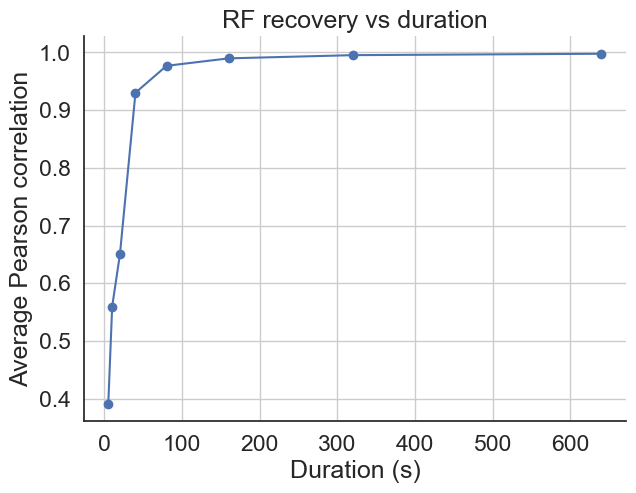

In [78]:
size = vf_size # size in pixel of our receptive field
mu = (8, 8) # center of the gabor pathc
sigma = (4,4) #size of the gabor patch
angle = 45 # orientation of the gabor patch
frequency = .085 # spatial frequency of the gabor patch
phase = 0 # pahse of the gabor pathc

xx, yy = np.meshgrid(1. + np.arange(size[0]),
                         1. + np.arange(size[1]))

# Gaussian envelope
G = np.exp(- np.power(xx - mu[0], 2) / (2. * sigma[0])
            - np.power(yy - mu[1], 2) / (2. * sigma[1]))

# spatial modulation
phi = np.deg2rad(angle)
xxr = xx * np.cos(phi)
yyr = yy * np.sin(phi)
xyr = (xxr + yyr) * 2. * np.pi * 2. * frequency
Sn = np.cos(xyr + phase)

K = G * Sn
K /= np.amax(np.abs(K))

noise_variance = 1
offset = 2.

# flatten the matrices in to 1d array for convenience
K_flat = K.ravel()
K_flat = np.hstack((K.flat, offset))

mean_cc = []
for d in duration: 
    cc_list = []

    # 10 realizations
    for i in range(10):
        n,S=data(d)
        
        S_flat = S.reshape(S.shape[0],S.shape[1]*S.shape[2])
        S_flat = np.hstack((S_flat, np.ones((n, 1))))
        
        # 1. linear stage
        ks = np.dot(K_flat, S_flat.T)
        
        # 2. nonlinear stage (for a linear model: f -> identity function)
        rate = ks
        
        # add Gaussian noise centered around the "true" rate for each bin
        rate = rate + np.sqrt(noise_variance) * np.random.randn(n)
        
        #S_flat = S_flat.T
        K_hat = np.linalg.pinv(S_flat.T @ S_flat) @ (S_flat.T @ rate)
        K_hat = K_hat[:-1].reshape(vf_size)
    
        #Pearson correlation
        cc=np.sum(K * K_hat)/(np.linalg.norm(K)*np.linalg.norm(K_hat))
        cc_list.append(cc)
    mean_cc.append(np.mean(cc_list))

# plot
plt.figure(figsize=(7, 5))
plt.plot(duration, mean_cc, 'o-')
plt.xlabel('Duration (s)')
plt.ylabel('Average Pearson correlation')
plt.title('RF recovery vs duration')
plt.grid()
plt.show()

> We first see a high increase for seconds between 5-100. This is because every second added gives a lot more information, also compared to the amount of noise added. After 100s we see that the Pearson correlation stays almost the same for higher seconds. This is because it already had enough information to correctly approximate K_true.

# Exercise 2

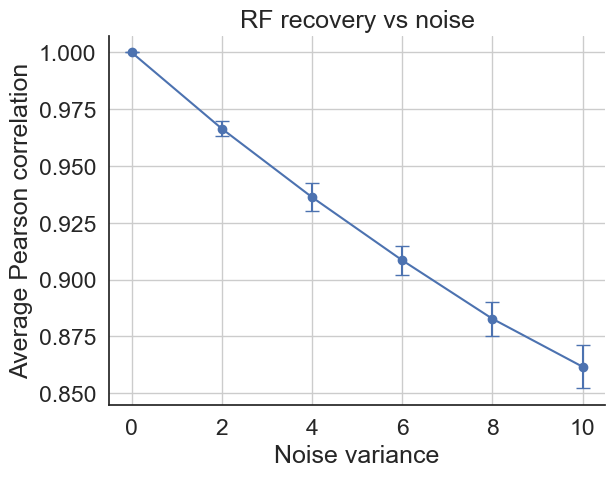

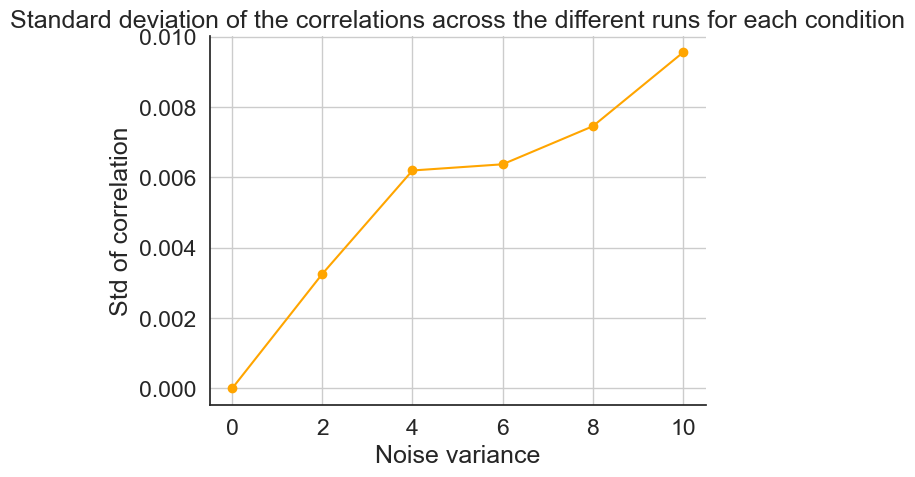

In [80]:
noise_variance = [0, 2, 4, 6, 8, 10] #different value for the noise variance 
n,S=data(100.) #duration of 100s

S_flat = S.reshape(S.shape[0],S.shape[1]*S.shape[2])
S_flat = np.hstack((S_flat, np.ones((n, 1))))

# 1. linear stage
ks = np.dot(K_flat, S_flat.T)

mean_cc = []
std_cc = []
for noise in noise_variance: 
    cc_list = []
    # 10 realizations
    for i in range(10):  
        # 2. nonlinear stage (for a linear model: f -> identity function)
        rate = ks
        # add Gaussian noise centered around the "true" rate for each bin
        rate = rate + np.sqrt(noise) * np.random.randn(n)
        
        #S_flat = S_flat.T
        K_hat = np.linalg.pinv(S_flat.T @ S_flat) @ (S_flat.T @ rate)
        K_hat = K_hat[:-1].reshape(vf_size)

        #Pearson correlation
        cc=np.sum(K * K_hat)/(np.linalg.norm(K)*np.linalg.norm(K_hat))
        cc_list.append(cc)    
    mean_cc.append(np.mean(cc_list))
    std_cc.append(np.std(cc_list))
    
plt.figure()
plt.errorbar(noise_variance, mean_cc, yerr=std_cc, marker='o', capsize=5)
plt.xlabel('Noise variance')
plt.ylabel('Average Pearson correlation')
plt.title('RF recovery vs noise')
plt.grid()
plt.show()

plt.figure()
plt.plot(noise_variance, std_cc, 'o-', color='orange')
plt.xlabel('Noise variance')
plt.ylabel('Std of correlation')
plt.title('Standard deviation of the correlations across the different runs for each condition')
plt.grid()
plt.show()

> As the noise variance grows, the standard deviation increases as well. Which is also visible in the decrease of the mean correlation. So a high noise variance makes the signal less clear and thus true RF parameters are harder to estimate and so the cc decreases. The standard deviation increases because each realization is more random and unstable.